<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/environment/SamplingAndAliasing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color='red'> Sampling and Aliasing

**by Alejandro Benitez-Llambay (alejandro.benitezllambay@unimib.it)** for the lab on "Signal and Imaging Acquisition and Modelling in Environment", of the Master in Artificial Inteligence for Science and Technology (AI4ST) at UNIMIB.


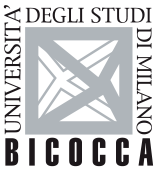

This notebook demonstrates the intrinsic limitations of sampled data. We will explore 1D temporal aliasing, 2D spatial aliasing (Moiré patterns), and how these signal processing principles directly cause standard Convolutional Neural Networks (CNNs) to fail.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import tensorflow as tf

## Exercise 1: 1D Signal Aliasing

We simulate a true $50\text{ Hz}$ physical signal (e.g., a machine vibration) but sample it at $60\text{ Hz}$. According to the Nyquist theorem ($f_s > 2 f_{max}$), this sampling rate is too low. We will then fit a simple continuous sine wave to our collected samples to see what the computer "believes" the reality is.

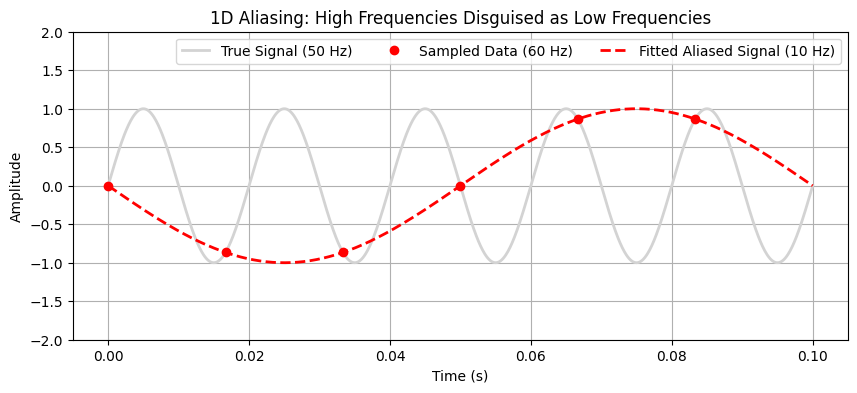

In [2]:
# 1. Simulate the "Continuous" True Signal
t_cont = np.linspace(0, 0.1, 1000) # 0.1 seconds
f_true = 50
y_cont = np.sin(2 * np.pi * f_true * t_cont)

# 2. Sample the signal at 60 Hz (Violating Nyquist)
f_sample = 60
t_samp = np.arange(0, 0.1, 1/f_sample)
y_samp = np.sin(2 * np.pi * f_true * t_samp)

# 3. Fit (by hand) a simple sine wave to the samples
# A 50 Hz signal sampled at 60 Hz aliases to 10 Hz.
# (Note: the negative sign accounts for the phase inversion during aliasing)
f_alias = 10
y_alias = -np.sin(2 * np.pi * f_alias * t_cont)

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(t_cont, y_cont, color='lightgray', linewidth=2, label='True Signal (50 Hz)')
plt.plot(t_samp, y_samp, 'ro', label=f'Sampled Data ({f_sample} Hz)')
plt.plot(t_cont, y_alias, 'r--', linewidth=2, label=f'Fitted Aliased Signal ({f_alias} Hz)')

plt.title("1D Aliasing: High Frequencies Disguised as Low Frequencies")
plt.ylim(-2,2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right', ncol=3)
plt.grid()

plt.show()

Let's now check whether we can reconstruct the signal if we sample it with a  sampling rate that is twice the original frequency. For this we will use a Whittaker-Shannon Interpolation (This is not important for us, as we won't study signal reconstruction), but it gives you an idea of how good or bad we do when undersampling the function.

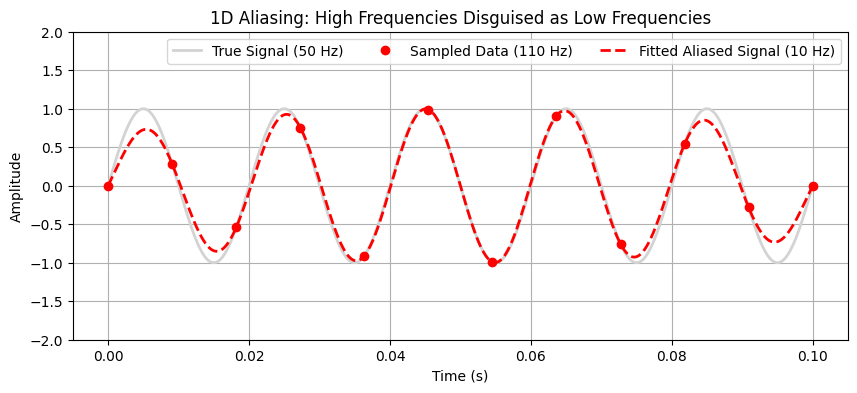

In [3]:
# 1. Simulate the "Continuous" True Signal
t_cont = np.linspace(0, 0.1, 1000) # 0.1 seconds
f_true = 50
y_cont = np.sin(2 * np.pi * f_true * t_cont)

# 2. Sample the signal at 60 Hz (Violating Nyquist)
f_sample = 110
T_s = 1.0 / f_sample
t_samp = np.arange(0, 0.1, T_s)
y_samp = np.sin(2 * np.pi * f_true * t_samp)

# 3. RECONSTRUCTION: Whittaker-Shannon Interpolation
# We reconstruct the continuous signal solely from the discrete y_samp points.
# Note: numpy's sinc function is defined as sin(pi*x)/(pi*x)
y_recon = np.zeros_like(t_cont)
for n, t_n in enumerate(t_samp):
    # Add the sinc function centered at t_n, scaled by the sample value y_samp[n]
    y_recon += y_samp[n] * np.sinc((t_cont - t_n) / T_s)

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(t_cont, y_cont, color='lightgray', linewidth=2, label='True Signal (50 Hz)')
plt.plot(t_samp, y_samp, 'ro', label=f'Sampled Data ({f_sample} Hz)')
plt.plot(t_cont, y_recon, 'r--', linewidth=2, label=f'Fitted Aliased Signal ({f_alias} Hz)')

plt.title("1D Aliasing: High Frequencies Disguised as Low Frequencies")
plt.ylim(-2,2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right', ncol=3)
plt.grid()

plt.show()

## Exercise 2: 2D Spatial Subsampling & Moiré Patterns
We will generate a synthetic 2D signal called a "Zone Plate." It is a pattern of concentric rings where the spatial frequency increases squarely as you move away from the center.

We will then subsample this image naively by skipping pixels (a stride of 3). This simulates bad image resizing or a standard convolutional stride without prior filtering. Watch what happens to the high-frequency rings on the outside.

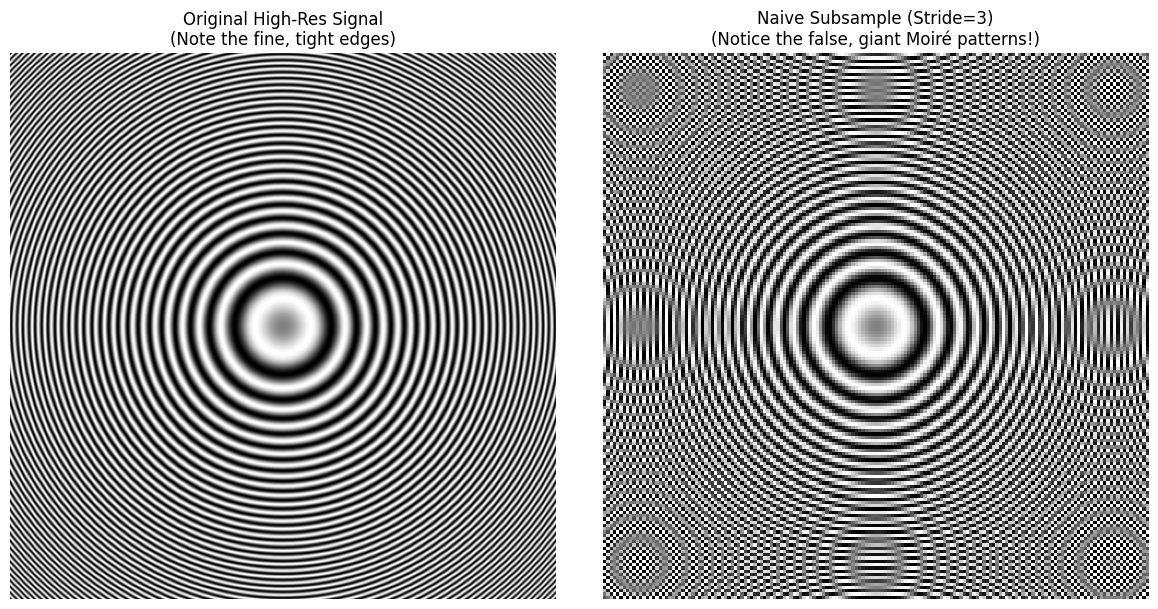

In [4]:
# 1. Generate the High-Resolution 2D Signal (Zone Plate)
size = 500
x = np.linspace(-1, 1, size)
y = np.linspace(-1, 1, size)
X, Y = np.meshgrid(x, y)

# The frequency increases squarely with distance from center
Z_high_res = np.sin(150 * (X**2 + Y**2))

# 2. Naive Subsampling (Simulating a simple strided operation)
stride = 3
Z_naive = Z_high_res[::stride, ::stride]

# Plotting the failure
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(Z_high_res, cmap='gray', extent=[-1, 1, -1, 1])
axes[0].set_title("Original High-Res Signal\n(Note the fine, tight edges)")
axes[0].axis('off')

axes[1].imshow(Z_naive, cmap='gray', extent=[-1, 1, -1, 1])
axes[1].set_title(f"Naive Subsample (Stride={stride})\n(Notice the false, giant Moiré patterns!)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Exercise 3: Mitigating 2D Aliasing with a Low-Pass Filter
Once you lower the resolution, the tight outer rings are gone forever—you cannot save high frequencies if you don't have the pixels for them.

However, we must prevent those high frequencies from folding over and turning into fake geometric structures (aliasing). To do this, we apply a **Gaussian Blur (low-pass filter)** before we subsample. This mathematically destroys the dangerous high frequencies so they die quietly into a smooth gray, rather than hallucinating new patterns.

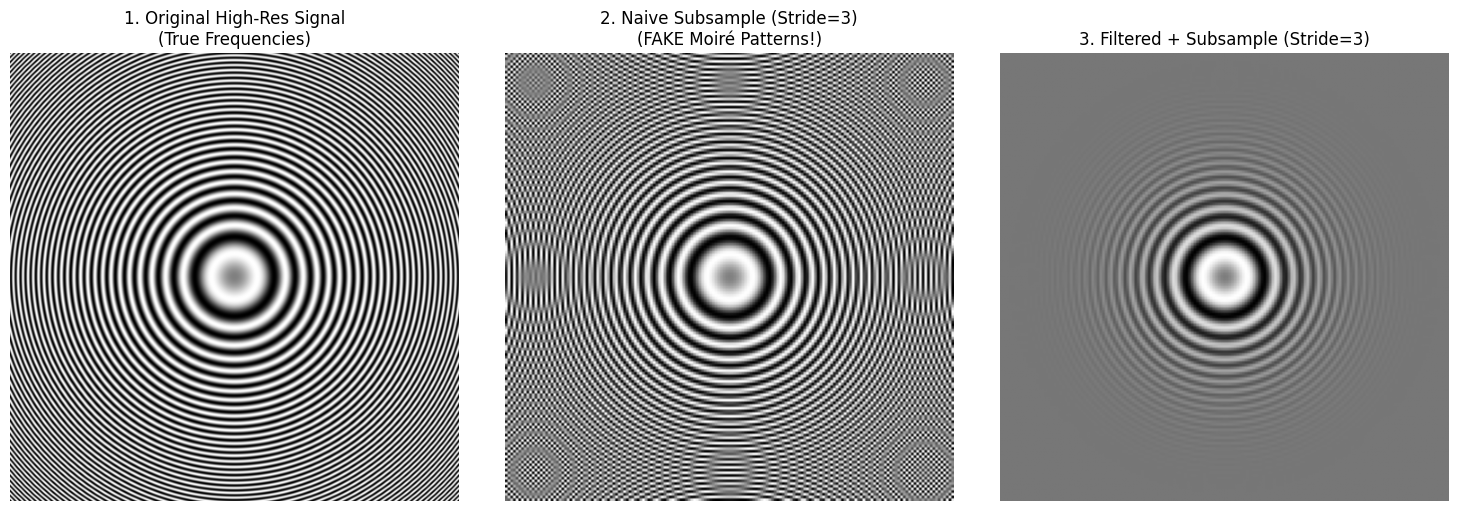

In [7]:
# 1. Generate a SLIGHTLY LARGER High-Resolution Signal (600x600 instead of 500x500)
# We add 50 pixels of padding on all sides to act as a mathematical "buffer"
size_padded = 600
# -1.2 to 1.2 maintains the exact same spatial scale for our inner 500x500 region (-1 to 1)
x = np.linspace(-1.2, 1.2, size_padded)
y = np.linspace(-1.2, 1.2, size_padded)
X, Y = np.meshgrid(x, y)

# Generate the signal
Z_large = np.sin(150 * (X**2 + Y**2))

# 2. Apply the Gaussian filter to the LARGE image
# The filter has plenty of real mathematical data to use at the -1 to 1 boundaries
Z_blurred_large = gaussian_filter(Z_large, sigma=3.0)

# 3. Crop both images back to the desired 500x500 area (removing the 50-pixel buffer)
crop = 50
Z_high_res = Z_large[crop:-crop, crop:-crop]
Z_blurred = Z_blurred_large[crop:-crop, crop:-crop]

# 4. Safely Subsample the cropped images
stride = 3
Z_naive = Z_high_res[::stride, ::stride]
Z_anti_aliased = Z_blurred[::stride, ::stride]

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(Z_high_res, cmap='gray', extent=[-1, 1, -1, 1])
axes[0].set_title("1. Original High-Res Signal\n(True Frequencies)")
axes[0].axis('off')

axes[1].imshow(Z_naive, cmap='gray', extent=[-1, 1, -1, 1])
axes[1].set_title(f"2. Naive Subsample (Stride={stride})\n(FAKE Moiré Patterns!)")
axes[1].axis('off')

axes[2].imshow(Z_anti_aliased, cmap='gray', extent=[-1, 1, -1, 1])
axes[2].set_title(f"3. Filtered + Subsample (Stride={stride})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Exercise 4: How CNNs Fail (Shift-Variance)

Standard deep learning architectures combine feature extraction and subsampling into a single step (e.g., `Conv1D(stride=2)` in 1D, or `Conv2D(stride=(3,3))` in 2D).

This violates standard signal processing techniques, and can lead to undesired consequences.

Let's see this problem. For this, we will create an edge detector and show how a 1-pixel shift completely destroys the network's output.

In [8]:
# 1. Edge detector kernel (High-pass filter)
kernel_weights = np.array([-1.0, 1.0]).reshape(2, 1, 1)

# 2. Standard CNN Block (Extraction and Subsampling combined)
model_standard = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(8, 1)),
    tf.keras.layers.Conv1D(filters=1, kernel_size=2, strides=2, use_bias=False)
])
model_standard.layers[0].set_weights([kernel_weights])

# 3. Create original signal and a 1-pixel shifted version
signal_orig = np.array([0, 0, 0, 10, 10, 10, 10, 10], dtype=np.float32).reshape(1, 8, 1)
signal_shift = np.array([0, 0, 0, 0, 10, 10, 10, 10], dtype=np.float32).reshape(1, 8, 1)

print("--- STANDARD CNN BLOCK ---")
print(f"Original Input: {signal_orig.flatten()}")
print(f"Output:         {model_standard.predict(signal_orig, verbose=0).flatten()}\n")

print(f"Shifted Input:  {signal_shift.flatten()}")
print(f"Output:         {model_standard.predict(signal_shift, verbose=0).flatten()} <-- BLIND TO FEATURE!")

--- STANDARD CNN BLOCK ---
Original Input: [ 0.  0.  0. 10. 10. 10. 10. 10.]
Output:         [ 0. 10.  0.  0.]

Shifted Input:  [ 0.  0.  0.  0. 10. 10. 10. 10.]
Output:         [0. 0. 0. 0.] <-- BLIND TO FEATURE!


## Exercise 4: Fixing CNNs with Anti-Aliasing (BlurPool)

To fix this, we can apply a similar logic that we developed for the image above. This is, decouple the operations.

We can first extract the feature densely (`stride=1`); then apply a low-pass filter to protect the feature map, and then safely downsample (`stride=2`).

In [9]:
# 1. Weights for feature extraction and low-pass filter
edge_weights = np.array([-1.0, 1.0]).reshape(2, 1, 1)
blur_weights = np.array([0.25, 0.5, 0.25]).reshape(3, 1, 1)

# 2. Anti-Aliased CNN Block (Decoupled extraction and subsampling)
model_aa = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(8, 1)),

    # Step A: Dense Extraction (Stride 1)
    tf.keras.layers.Conv1D(filters=1, kernel_size=2, strides=1, padding='valid', use_bias=False),

    # Step B: Blur and Subsample (Stride 2)
    tf.keras.layers.Conv1D(filters=1, kernel_size=3, strides=2, padding='same', use_bias=False)
])

model_aa.layers[0].set_weights([edge_weights])
model_aa.layers[1].set_weights([blur_weights])

print("--- ANTI-ALIASED CNN BLOCK ---")
print(f"Original Input: {signal_orig.flatten()}")
print(f"Output:         {model_aa.predict(signal_orig, verbose=0).flatten()}\n")

print(f"Shifted Input:  {signal_shift.flatten()}")
print(f"Output:         {model_aa.predict(signal_shift, verbose=0).flatten()} <-- FEATURE RETAINED!")

--- ANTI-ALIASED CNN BLOCK ---
Original Input: [ 0.  0.  0. 10. 10. 10. 10. 10.]
Output:         [0. 5. 0. 0.]

Shifted Input:  [ 0.  0.  0.  0. 10. 10. 10. 10.]
Output:         [0.  2.5 2.5 0. ] <-- FEATURE RETAINED!
